# DeepSeek MLA vs GQA vs MHA — PyTorch Benchmark
**Real GPU benchmarks**: KV cache memory and decode latency across Standard MHA, Grouped Query Attention, and DeepSeek Multi-Head Latent Attention.

Sections:
1. Setup & Adaptive Config
2a. Standard MHA
2b. Grouped Query Attention (GQA)
2c. DeepSeek MLA
3. Correctness Tests
4. Memory Benchmark
5. Decode Latency Benchmark
6. Results & Graphs

## Part 1: Setup & Adaptive Config

In [1]:
# ── Part 1: Setup & Adaptive Config ──────────────────────────────────────────
!pip install -q torch matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time
import matplotlib.pyplot as plt
import numpy as np

# ── GPU detection ─────────────────────────────────────────────────────────────
assert torch.cuda.is_available(), "No GPU found — switch runtime to GPU"

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"GPU  : {gpu_name}")
print(f"VRAM : {vram_gb:.1f} GB")

# ── Tier selection ────────────────────────────────────────────────────────────
if "H100" in gpu_name:
    tier = "H100"
    SEQ_LENS   = [1024, 2048, 4096, 8192, 16384, 32768]
    BATCH_SIZE = 2
    DTYPE      = torch.bfloat16
elif "A100" in gpu_name:
    tier = "A100"
    SEQ_LENS   = [1024, 2048, 4096, 8192, 16384]
    BATCH_SIZE = 1
    DTYPE      = torch.bfloat16
else:                          # T4 / V100 fallback
    tier = "T4"
    SEQ_LENS   = [1024, 2048, 4096, 8192, 16384]
    BATCH_SIZE = 1
    DTYPE      = torch.float16

# ── Model hyperparameters ─────────────────────────────────────────────────────
NUM_HEADS    = 128       # DeepSeek-V3 config (was 32)
HEAD_DIM     = 128
NUM_KV_HEADS = 8          # GQA: 8 KV heads, 128 Q heads
KV_LORA_RANK = 512        # MLA compressed KV dim
ROPE_DIM     = 64         # MLA decoupled RoPE dim per head
D_MODEL      = NUM_HEADS * HEAD_DIM

DEVICE = torch.device("cuda:0")

print(f"\nTier        : {tier}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Dtype       : {DTYPE}")
print(f"Seq lens    : {SEQ_LENS}")
print(f"d_model     : {D_MODEL}  ({NUM_HEADS} heads x {HEAD_DIM} head_dim)")
print(f"KV_LORA_RANK: {KV_LORA_RANK}")
print(f"ROPE_DIM    : {ROPE_DIM}")

GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB

Tier        : A100
Batch size  : 1
Dtype       : torch.bfloat16
Seq lens    : [1024, 2048, 4096, 8192, 16384]
d_model     : 16384  (128 heads x 128 head_dim)
KV_LORA_RANK: 512
ROPE_DIM    : 64


In [2]:
# KV_LORA_RANK = 512  (DeepSeek-V3 technical report, arxiv:2412.19437, §2.1)
#
# MLA cache per token  =  kv_lora_rank + num_heads * rope_dim
# MHA cache per token  =  2 * num_heads * head_dim
_mla_tok = KV_LORA_RANK + NUM_HEADS * ROPE_DIM
_mha_tok = 2 * NUM_HEADS * HEAD_DIM
print(f"[arxiv:2412.19437]  KV_LORA_RANK={KV_LORA_RANK}  (DeepSeek-V3 §2.1)")
print(f"  MLA cache/token = kv_lora_rank + num_heads×rope_dim")
print(f"                  = {KV_LORA_RANK} + {NUM_HEADS}×{ROPE_DIM} = {_mla_tok:,} elements")
print(f"  MHA cache/token = 2×num_heads×head_dim")
print(f"                  = 2×{NUM_HEADS}×{HEAD_DIM}        = {_mha_tok:,} elements")
print(f"  Theoretical cache reduction: {_mha_tok / _mla_tok:.2f}x")

[arxiv:2412.19437]  KV_LORA_RANK=512  (DeepSeek-V3 §2.1)
  MLA cache/token = kv_lora_rank + num_heads×rope_dim
                  = 512 + 128×64 = 8,704 elements
  MHA cache/token = 2×num_heads×head_dim
                  = 2×128×128        = 32,768 elements
  Theoretical cache reduction: 3.76x


## Part 2: Attention Implementations

This implementation uses `F.scaled_dot_product_attention` — PyTorch's built-in FlashAttention-2-backed kernel on Ampere+ GPUs. On H100, PyTorch dispatches to FlashAttention-3 via cuDNN. No manual FA integration is needed for correctness benchmarks, but production serving stacks (e.g. vLLM) would layer PagedAttention on top for paged KV cache management.

## Part 2a: Standard MHA

In [3]:
# ── Part 2a: Standard Multi-Head Attention ────────────────────────────────────
class StandardMHA(nn.Module):
    """
    Vanilla MHA with a growing KV cache for autoregressive decode.
    Cache shape: k/v each (batch, num_heads, seq, head_dim).
    """
    def __init__(self, d_model, num_heads, head_dim, dtype=torch.bfloat16):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = head_dim

        self.q_proj   = nn.Linear(d_model, num_heads * head_dim, bias=False, dtype=dtype)
        self.k_proj   = nn.Linear(d_model, num_heads * head_dim, bias=False, dtype=dtype)
        self.v_proj   = nn.Linear(d_model, num_heads * head_dim, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(num_heads * head_dim, d_model, bias=False, dtype=dtype)

    def forward(self, x, kv_cache=None):
        """
        x        : (batch, seq, d_model)
        kv_cache : dict with 'k','v' tensors, or None for prefill
        returns  : (output, updated_kv_cache)
        """
        B, T, _ = x.shape
        H, D    = self.num_heads, self.head_dim

        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)  # (B, H, T, D)
        k = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)

        # append new k/v to cache during decode
        if kv_cache is not None:
            k = torch.cat([kv_cache['k'], k], dim=2)
            v = torch.cat([kv_cache['v'], v], dim=2)

        new_cache = {'k': k, 'v': v}

        # causal mask only during prefill (full sequence, no prior cache)
        is_prefill = (T > 1 and kv_cache is None)
        attn = F.scaled_dot_product_attention(q, k, v, is_causal=is_prefill)

        out = attn.transpose(1, 2).reshape(B, T, H * D)
        return self.out_proj(out), new_cache


# ── Smoke test ────────────────────────────────────────────────────────────────
mha = StandardMHA(D_MODEL, NUM_HEADS, HEAD_DIM, dtype=DTYPE).to(DEVICE)
x   = torch.randn(1, 16, D_MODEL, dtype=DTYPE, device=DEVICE)
out, cache = mha(x)
print(f"StandardMHA output : {out.shape}")
print(f"KV cache k shape   : {cache['k'].shape}")
print("StandardMHA  OK")

StandardMHA output : torch.Size([1, 16, 16384])
KV cache k shape   : torch.Size([1, 128, 16, 128])
StandardMHA  OK


## Part 2b: Grouped Query Attention (GQA)

In [4]:
# ── Part 2b: Grouped Query Attention (GQA) ───────────────────────────────────
class GroupedQueryAttention(nn.Module):
    """
    GQA: num_q_heads query heads share num_kv_heads key/value heads.
    Production baseline — used in LLaMA 3, Mistral, Qwen.
    Cache shape: k/v each (batch, num_kv_heads, seq, head_dim).
    """
    def __init__(self, d_model, num_q_heads, num_kv_heads, head_dim, dtype=torch.bfloat16):
        super().__init__()
        assert num_q_heads % num_kv_heads == 0, "num_q_heads must be divisible by num_kv_heads"
        self.num_q_heads  = num_q_heads
        self.num_kv_heads = num_kv_heads
        self.head_dim     = head_dim
        self.groups       = num_q_heads // num_kv_heads  # Q heads per KV head

        self.q_proj   = nn.Linear(d_model, num_q_heads  * head_dim, bias=False, dtype=dtype)
        self.k_proj   = nn.Linear(d_model, num_kv_heads * head_dim, bias=False, dtype=dtype)
        self.v_proj   = nn.Linear(d_model, num_kv_heads * head_dim, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(num_q_heads * head_dim, d_model,  bias=False, dtype=dtype)

    def forward(self, x, kv_cache=None):
        """
        x        : (batch, seq, d_model)
        kv_cache : dict with 'k','v' tensors, or None for prefill
        returns  : (output, updated_kv_cache)
        """
        B, T, _ = x.shape
        Hq, Hkv, D = self.num_q_heads, self.num_kv_heads, self.head_dim

        q = self.q_proj(x).view(B, T, Hq,  D).transpose(1, 2)   # (B, Hq,  T, D)
        k = self.k_proj(x).view(B, T, Hkv, D).transpose(1, 2)   # (B, Hkv, T, D)
        v = self.v_proj(x).view(B, T, Hkv, D).transpose(1, 2)

        if kv_cache is not None:
            k = torch.cat([kv_cache['k'], k], dim=2)
            v = torch.cat([kv_cache['v'], v], dim=2)

        new_cache = {'k': k, 'v': v}

        # expand KV heads to match Q heads for attention
        k = k.repeat_interleave(self.groups, dim=1)  # (B, Hq, seq, D)
        v = v.repeat_interleave(self.groups, dim=1)

        is_prefill = (T > 1 and kv_cache is None)
        attn = F.scaled_dot_product_attention(q, k, v, is_causal=is_prefill)

        out = attn.transpose(1, 2).reshape(B, T, Hq * D)
        return self.out_proj(out), new_cache


# ── Smoke test ────────────────────────────────────────────────────────────────
gqa = GroupedQueryAttention(D_MODEL, NUM_HEADS, NUM_KV_HEADS, HEAD_DIM, dtype=DTYPE).to(DEVICE)
x   = torch.randn(1, 16, D_MODEL, dtype=DTYPE, device=DEVICE)
out, cache = gqa(x)
print(f"GQA output       : {out.shape}")
print(f"KV cache k shape : {cache['k'].shape}  (only {NUM_KV_HEADS} KV heads, not {NUM_HEADS})")
print("GQA  OK")

GQA output       : torch.Size([1, 16, 16384])
KV cache k shape : torch.Size([1, 8, 16, 128])  (only 8 KV heads, not 128)
GQA  OK


## Part 2c: DeepSeek MLA

In [5]:
# ── Part 2c: DeepSeek Multi-Head Latent Attention (MLA) ──────────────────────
#
# Key idea: instead of caching full K and V tensors, cache a single compressed
# latent vector c_kv (shape: seq x kv_lora_rank) and recompute K,V on-the-fly.
# Only K's RoPE component is also cached (can't be recomputed without positions).
#
# Cache per token  =  kv_lora_rank  +  num_heads * rope_dim
# vs MHA per token =  2 * num_heads * head_dim
#
class DeepSeekMLA(nn.Module):
    def __init__(self, d_model, num_heads, head_dim, kv_lora_rank, rope_dim, dtype=torch.bfloat16):
        super().__init__()
        self.num_heads    = num_heads
        self.head_dim     = head_dim
        self.kv_lora_rank = kv_lora_rank
        self.rope_dim     = rope_dim
        self.content_dim  = head_dim - rope_dim   # non-RoPE part of each head

        # KV compression: d_model -> rank (this is what gets cached)
        self.kv_down_proj = nn.Linear(d_model, kv_lora_rank,          bias=False, dtype=dtype)
        # KV expansion: rank -> num_heads*head_dim (runs at every decode step, NOT cached)
        self.kv_up_proj   = nn.Linear(kv_lora_rank, num_heads * head_dim, bias=False, dtype=dtype)

        # Decoupled RoPE: bypasses compression so positions encode correctly
        self.k_rope_proj  = nn.Linear(d_model, num_heads * rope_dim,  bias=False, dtype=dtype)

        # Q path — Q is never cached so no compression needed for memory savings
        self.q_proj       = nn.Linear(d_model, num_heads * self.content_dim, bias=False, dtype=dtype)
        self.q_rope_proj  = nn.Linear(d_model, num_heads * rope_dim,         bias=False, dtype=dtype)

        self.out_proj     = nn.Linear(num_heads * head_dim, d_model, bias=False, dtype=dtype)

    def _rope(self, x, positions):
        """Rotary position embedding.  x: (B, H, T, rope_dim)  positions: (T,)"""
        half = x.shape[-1] // 2
        inv_freq = 1.0 / (10000 ** (torch.arange(0, half, device=x.device, dtype=torch.float32) / half))
        freqs = torch.outer(positions.float(), inv_freq)          # (T, half)
        cos = freqs.cos()[None, None].to(x.dtype)                 # (1, 1, T, half)
        sin = freqs.sin()[None, None].to(x.dtype)
        x1, x2 = x[..., :half], x[..., half:]
        return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)

    def forward(self, x, kv_cache=None):
        """
        x        : (batch, seq, d_model)
        kv_cache : dict with 'c_kv' (B,S,rank) and 'k_rope' (B,S,H,R), or None
        returns  : (output, updated_kv_cache)
        """
        B, T, _ = x.shape
        H = self.num_heads
        D = self.head_dim
        C = self.content_dim   # head_dim - rope_dim
        R = self.rope_dim

        cache_len = kv_cache['c_kv'].shape[1] if kv_cache is not None else 0
        positions = torch.arange(cache_len, cache_len + T, device=x.device)

        # ── Q path ────────────────────────────────────────────────────────────
        q_content = self.q_proj(x).view(B, T, H, C).transpose(1, 2)      # (B, H, T, C)
        q_rope    = self.q_rope_proj(x).view(B, T, H, R).transpose(1, 2)  # (B, H, T, R)
        q_rope    = self._rope(q_rope, positions)
        q         = torch.cat([q_content, q_rope], dim=-1)                 # (B, H, T, D)

        # ── KV compression (new tokens only) ──────────────────────────────────
        c_kv_new    = self.kv_down_proj(x)                                         # (B, T, rank)
        k_rope_new  = self.k_rope_proj(x).view(B, T, H, R).transpose(1, 2)        # (B, H, T, R)
        k_rope_new  = self._rope(k_rope_new, positions)
        k_rope_new  = k_rope_new.transpose(1, 2)                                   # (B, T, H, R) for storage

        # ── Append to cache ───────────────────────────────────────────────────
        if kv_cache is not None:
            c_kv   = torch.cat([kv_cache['c_kv'],   c_kv_new],  dim=1)  # (B, S+T, rank)
            k_rope = torch.cat([kv_cache['k_rope'], k_rope_new], dim=1)  # (B, S+T, H, R)
        else:
            c_kv   = c_kv_new
            k_rope = k_rope_new

        new_cache = {'c_kv': c_kv, 'k_rope': k_rope}

        # ── Expand compressed KV on-the-fly ───────────────────────────────────
        S    = c_kv.shape[1]
        kv   = self.kv_up_proj(c_kv).view(B, S, H, D)   # (B, S, H, D)
        k_content = kv[..., :C].transpose(1, 2)           # (B, H, S, C)
        v         = kv.transpose(1, 2)                    # (B, H, S, D)
        k         = torch.cat([k_content, k_rope.transpose(1, 2)], dim=-1)  # (B, H, S, D)

        is_prefill = (T > 1 and kv_cache is None)
        attn = F.scaled_dot_product_attention(q, k, v, is_causal=is_prefill)

        out = attn.transpose(1, 2).reshape(B, T, H * D)
        return self.out_proj(out), new_cache


# ── Smoke test + cache size comparison ───────────────────────────────────────
mla = DeepSeekMLA(D_MODEL, NUM_HEADS, HEAD_DIM, KV_LORA_RANK, ROPE_DIM, dtype=DTYPE).to(DEVICE)
x   = torch.randn(1, 16, D_MODEL, dtype=DTYPE, device=DEVICE)
out, cache = mla(x)

mha_cache_elems = 2 * NUM_HEADS * HEAD_DIM          # per token
mla_cache_elems = KV_LORA_RANK + NUM_HEADS * ROPE_DIM  # per token
gqa_cache_elems = 2 * NUM_KV_HEADS * HEAD_DIM       # per token

print(f"DeepSeekMLA output   : {out.shape}")
print(f"c_kv cache shape     : {cache['c_kv'].shape}")
print(f"k_rope cache shape   : {cache['k_rope'].shape}")
print()
print(f"Cache elements per token:")
print(f"  MHA : {mha_cache_elems:,}  (2 × {NUM_HEADS} heads × {HEAD_DIM} dim)")
print(f"  GQA : {gqa_cache_elems:,}  (2 × {NUM_KV_HEADS} kv_heads × {HEAD_DIM} dim)")
print(f"  MLA : {mla_cache_elems:,}  ({KV_LORA_RANK} rank + {NUM_HEADS}×{ROPE_DIM} rope)")
print(f"  MLA vs MHA reduction: {mha_cache_elems / mla_cache_elems:.2f}x")
print("DeepSeekMLA  OK")

DeepSeekMLA output   : torch.Size([1, 16, 16384])
c_kv cache shape     : torch.Size([1, 16, 512])
k_rope cache shape   : torch.Size([1, 16, 128, 64])

Cache elements per token:
  MHA : 32,768  (2 × 128 heads × 128 dim)
  GQA : 2,048  (2 × 8 kv_heads × 128 dim)
  MLA : 8,704  (512 rank + 128×64 rope)
  MLA vs MHA reduction: 3.76x
DeepSeekMLA  OK


## Part 3: Correctness Tests

In [6]:
# ── Part 3: Correctness Tests ─────────────────────────────────────────────────
# 4 checks — each prints PASS/FAIL.
# Strategy for cache consistency: prefill T tokens, decode token T+1 with cache,
# compare against a full forward pass over T+1 tokens (last token's output).

SEQ_TEST = 32   # short sequence for fast correctness checks
TOL      = 5e-2  # bfloat16 accumulates ~1e-2 per op; generous but meaningful


def test_mha_cache_consistency():
    """MHA: decode-with-cache output matches full-sequence output at same position."""
    model = StandardMHA(D_MODEL, NUM_HEADS, HEAD_DIM, dtype=DTYPE).to(DEVICE).eval()
    x = torch.randn(1, SEQ_TEST + 1, D_MODEL, dtype=DTYPE, device=DEVICE)

    with torch.no_grad():
        out_full, _    = model(x)                                      # full, no cache
        _,        cache = model(x[:, :SEQ_TEST, :])                    # prefill
        out_decode, _  = model(x[:, SEQ_TEST:SEQ_TEST+1, :], kv_cache=cache)  # decode step

    diff   = (out_full[:, SEQ_TEST:SEQ_TEST+1, :] - out_decode).abs().max().item()
    passed = diff < TOL
    print(f"[{'PASS' if passed else 'FAIL'}] MHA  cache consistency       (max diff: {diff:.2e})")
    return passed


def test_gqa_equals_mha():
    """GQA with num_kv_heads == num_heads should be identical to MHA (same weights)."""
    mha = StandardMHA(D_MODEL, NUM_HEADS, HEAD_DIM, dtype=DTYPE).to(DEVICE).eval()
    gqa = GroupedQueryAttention(D_MODEL, NUM_HEADS, NUM_HEADS, HEAD_DIM, dtype=DTYPE).to(DEVICE).eval()

    with torch.no_grad():
        gqa.q_proj.weight.copy_(mha.q_proj.weight)
        gqa.k_proj.weight.copy_(mha.k_proj.weight)
        gqa.v_proj.weight.copy_(mha.v_proj.weight)
        gqa.out_proj.weight.copy_(mha.out_proj.weight)

    x = torch.randn(1, SEQ_TEST, D_MODEL, dtype=DTYPE, device=DEVICE)
    with torch.no_grad():
        out_mha, _ = mha(x)
        out_gqa, _ = gqa(x)

    diff   = (out_mha - out_gqa).abs().max().item()
    passed = diff < TOL
    print(f"[{'PASS' if passed else 'FAIL'}] GQA == MHA (kv_heads=heads)  (max diff: {diff:.2e})")
    return passed


def test_mla_cache_consistency():
    """MLA: decode-with-cache output matches full-sequence output at same position."""
    model = DeepSeekMLA(
        D_MODEL, NUM_HEADS, HEAD_DIM, KV_LORA_RANK, ROPE_DIM, dtype=DTYPE
    ).to(DEVICE).eval()
    x = torch.randn(1, SEQ_TEST + 1, D_MODEL, dtype=DTYPE, device=DEVICE)

    with torch.no_grad():
        out_full, _    = model(x)
        _,        cache = model(x[:, :SEQ_TEST, :])
        out_decode, _  = model(x[:, SEQ_TEST:SEQ_TEST+1, :], kv_cache=cache)

    diff   = (out_full[:, SEQ_TEST:SEQ_TEST+1, :] - out_decode).abs().max().item()
    passed = diff < TOL
    print(f"[{'PASS' if passed else 'FAIL'}] MLA  cache consistency       (max diff: {diff:.2e})")
    return passed


def test_mla_cache_smaller_than_mha():
    """MLA KV cache bytes < MHA KV cache bytes at a representative sequence length."""
    seq   = 4096
    bytes_per_elem = 2  # bfloat16

    mha_bytes = 2 * NUM_HEADS    * HEAD_DIM                   * seq * bytes_per_elem
    gqa_bytes = 2 * NUM_KV_HEADS * HEAD_DIM                   * seq * bytes_per_elem
    mla_bytes = (KV_LORA_RANK + NUM_HEADS * ROPE_DIM)         * seq * bytes_per_elem

    passed = mla_bytes < mha_bytes
    print(f"[{'PASS' if passed else 'FAIL'}] MLA cache < MHA cache  (seq={seq})")
    print(f"         MHA : {mha_bytes/1e6:.1f} MB")
    print(f"         GQA : {gqa_bytes/1e6:.1f} MB")
    print(f"         MLA : {mla_bytes/1e6:.1f} MB")
    print(f"         MLA vs MHA : {mha_bytes/mla_bytes:.2f}x smaller")
    print(f"         MLA vs GQA : {mla_bytes/gqa_bytes:.2f}x larger")
    return passed


# ── Run all tests ─────────────────────────────────────────────────────────────
print("=" * 55)
results = [
    test_mha_cache_consistency(),
    test_gqa_equals_mha(),
    test_mla_cache_consistency(),
    test_mla_cache_smaller_than_mha(),
]
print("=" * 55)
print(f"Passed {sum(results)}/{len(results)} tests")

[PASS] MHA  cache consistency       (max diff: 1.95e-03)
[PASS] GQA == MHA (kv_heads=heads)  (max diff: 0.00e+00)
[PASS] MLA  cache consistency       (max diff: 9.77e-04)
[PASS] MLA cache < MHA cache  (seq=4096)
         MHA : 268.4 MB
         GQA : 16.8 MB
         MLA : 71.3 MB
         MLA vs MHA : 3.76x smaller
         MLA vs GQA : 4.25x larger
Passed 4/4 tests


## Part 4: Memory Benchmark

In [7]:
# ── Part 4: Memory Benchmark ──────────────────────────────────────────────────
# Measures actual GPU memory occupied by the KV cache after a prefill pass.
# Uses batch=1 so numbers represent per-sequence cache cost (scales linearly).
# Models are created once; memory delta after (forward + del input) = cache bytes.

BENCH_BATCH = 1   # isolate per-sequence cache cost

@torch.no_grad()
def measure_cache_mb(model, seq_len):
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    mem_baseline = torch.cuda.memory_allocated()

    x = torch.randn(BENCH_BATCH, seq_len, D_MODEL, dtype=DTYPE, device=DEVICE)
    _, cache = model(x)
    del x                          # free input; cache tensors stay alive
    torch.cuda.synchronize()

    cache_mb = (torch.cuda.memory_allocated() - mem_baseline) / 1e6

    del cache
    torch.cuda.empty_cache()
    return cache_mb


# ── Instantiate models once ───────────────────────────────────────────────────
mha_model = StandardMHA(D_MODEL, NUM_HEADS, HEAD_DIM, dtype=DTYPE).to(DEVICE).eval()
gqa_model = GroupedQueryAttention(D_MODEL, NUM_HEADS, NUM_KV_HEADS, HEAD_DIM, dtype=DTYPE).to(DEVICE).eval()
mla_model = DeepSeekMLA(D_MODEL, NUM_HEADS, HEAD_DIM, KV_LORA_RANK, ROPE_DIM, dtype=DTYPE).to(DEVICE).eval()

# ── Run benchmark ─────────────────────────────────────────────────────────────
mem_results = {'seq_lens': [], 'mha': [], 'gqa': [], 'mla': []}

print(f"{'Seq Len':>10}  {'MHA (MB)':>10}  {'GQA (MB)':>10}  {'MLA (MB)':>10}  {'MHA/MLA':>8}  {'GQA/MLA':>8}")
print("-" * 65)

for seq_len in SEQ_LENS:
    try:
        mha_mb = measure_cache_mb(mha_model, seq_len)
        gqa_mb = measure_cache_mb(gqa_model, seq_len)
        mla_mb = measure_cache_mb(mla_model, seq_len)

        mem_results['seq_lens'].append(seq_len)
        mem_results['mha'].append(mha_mb)
        mem_results['gqa'].append(gqa_mb)
        mem_results['mla'].append(mla_mb)

        print(f"{seq_len:>10,}  {mha_mb:>10.1f}  {gqa_mb:>10.1f}  {mla_mb:>10.1f}"
              f"  {mha_mb/mla_mb:>8.2f}x  {gqa_mb/mla_mb:>8.2f}x")
    except torch.cuda.OutOfMemoryError:
        print(f"OOM at seq_len={seq_len}, skipping")
        torch.cuda.empty_cache()
        continue

print("-" * 65)
print(f"GPU: {gpu_name}  |  batch=1  |  dtype={DTYPE}")

   Seq Len    MHA (MB)    GQA (MB)    MLA (MB)   MHA/MLA   GQA/MLA
-----------------------------------------------------------------
     1,024       100.7        37.7        51.4      1.96x      0.73x
     2,048       201.3        75.5       102.8      1.96x      0.73x
     4,096       402.7       151.0       205.5      1.96x      0.73x
     8,192       805.3       302.0       411.0      1.96x      0.73x
    16,384      1610.6       604.0       822.1      1.96x      0.73x
-----------------------------------------------------------------
GPU: NVIDIA A100-SXM4-40GB  |  batch=1  |  dtype=torch.bfloat16


## Part 4b: PyTorch Profiler

In [8]:
# ── Part 4b: PyTorch Profiler ─────────────────────────────────────────────────
# Uses the already-instantiated mha_model, gqa_model, mla_model from Part 4.
# Prefills PROFILE_SEQ tokens then profiles a single decode step.
# Top-10 CUDA kernels sorted by self_cuda_time_total.
# Chrome traces exported to mla_profile_{model_name}.json.
from torch.profiler import ProfilerActivity

PROFILE_SEQ  = 4096
WARMUP_STEPS = 5

@torch.no_grad()
def profile_decode_step(model, model_name):
    torch.cuda.empty_cache()
    x_pre = torch.randn(BENCH_BATCH, PROFILE_SEQ, D_MODEL, dtype=DTYPE, device=DEVICE)
    _, cache = model(x_pre)
    del x_pre
    cache_snapshot = {k: v.clone() for k, v in cache.items()}
    del cache

    x_dec = torch.randn(BENCH_BATCH, 1, D_MODEL, dtype=DTYPE, device=DEVICE)

    for _ in range(WARMUP_STEPS):
        model(x_dec, kv_cache={k: v.clone() for k, v in cache_snapshot.items()})

    with torch.profiler.profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        profile_memory=True,
        record_shapes=True,
    ) as prof:
        model(x_dec, kv_cache={k: v.clone() for k, v in cache_snapshot.items()})

    trace_file = f"mla_profile_{model_name}.json"
    print(f"\n── {model_name.upper()} Profile  (prefill={PROFILE_SEQ}, decode 1 token) ──")
    print(prof.key_averages().table(sort_by="self_cuda_time_total", row_limit=10))
    prof.export_chrome_trace(trace_file)
    print(f"Chrome trace saved: {trace_file}")

    del x_dec, cache_snapshot
    torch.cuda.empty_cache()


for _name, _model in [('mha', mha_model), ('gqa', gqa_model), ('mla', mla_model)]:
    profile_decode_step(_model, _name)


── MHA Profile  (prefill=4096, decode 1 token) ──
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         5.05%     390.925us         7.42%     573.753us     143.438us       1.566ms        44.66%       1.566ms     391.422us    

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


## Part 4c: Memory Timeline Snapshot

In [9]:
# ── Part 4c: Memory Timeline Snapshot ─────────────────────────────────────────
# Re-runs prefill at each model at the largest seq_len with memory history
# recording enabled.  Saves a Pickle snapshot compatible with pytorch.org/memory_viz.
# Prints peak allocated and peak reserved per model.
import pickle

torch.cuda.memory._record_memory_history(max_entries=100000)

mem_peak_results = {}
for name, model in [('mha', mha_model), ('gqa', gqa_model), ('mla', mla_model)]:
    try:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
        x = torch.randn(BENCH_BATCH, SEQ_LENS[-1], D_MODEL, dtype=DTYPE, device=DEVICE)
        with torch.no_grad():
            _, cache = model(x)
        del x
        torch.cuda.synchronize()
        mem_peak_results[name] = {
            'peak_alloc_mb':    torch.cuda.max_memory_allocated() / 1e6,
            'peak_reserved_mb': torch.cuda.max_memory_reserved()  / 1e6,
        }
        del cache
        torch.cuda.empty_cache()
    except torch.cuda.OutOfMemoryError:
        print(f"OOM for {name} at seq_len={SEQ_LENS[-1]}, skipping")
        torch.cuda.empty_cache()
        continue

snapshot = torch.cuda.memory._snapshot()
with open('mla_memory_snapshot.pkl', 'wb') as f:
    pickle.dump(snapshot, f)
torch.cuda.memory._record_memory_history(enabled=None)

print("Memory snapshot saved: mla_memory_snapshot.pkl")
print(f"\nPeak memory at largest seq_len ({SEQ_LENS[-1]:,} tokens):")
print(f"{'Model':>6}  {'Peak Alloc (MB)':>16}  {'Peak Reserved (MB)':>18}")
print("-" * 46)
for name in ['mha', 'gqa', 'mla']:
    if name in mem_peak_results:
        pa = mem_peak_results[name]['peak_alloc_mb']
        pr = mem_peak_results[name]['peak_reserved_mb']
        print(f"{name.upper():>6}  {pa:>14.1f}  {pr:>16.1f}")
    else:
        print(f"{name.upper():>6}  {'OOM':>14}  {'OOM':>16}")

Memory snapshot saved: mla_memory_snapshot.pkl

Peak memory at largest seq_len (16,384 tokens):
 Model   Peak Alloc (MB)  Peak Reserved (MB)
----------------------------------------------
   MHA         12561.8           12744.4
   GQA         13165.6           13281.3
   MLA         14457.5           15430.8


## Part 5: Decode Latency Benchmark

⚠️ **Note:** This original benchmark has a methodology bug — the KV cache grows across the 20 measurement steps, so each step measures decode latency at a different (and increasing) context length rather than the intended fixed length. The corrected version is in **Part 5 (Fixed)** below. The numbers in this cell are kept for transparency but **should not be cited** — use Part 5 (Fixed) results instead.

In [10]:
# ── Part 5: Decode Latency Benchmark ─────────────────────────────────────────
# For each context length: prefill to that length, then time single-token decode.
# This shows how ms/token changes as the KV cache grows — the key serving metric.
#
# MLA trade-off: smaller cache BUT it up-projects the full cached c_kv every step.
# Expect MLA latency to rise faster than MHA/GQA at long contexts — that crossover
# point is the interesting finding for the blog.

WARMUP_STEPS  = 5
MEASURE_STEPS = 20


@torch.no_grad()
def measure_decode_latency_ms(model, ctx_len):
    """
    Prefill ctx_len tokens, warmup, then time MEASURE_STEPS single-token decode steps.
    Returns mean ms/token.
    """
    torch.cuda.empty_cache()

    # prefill
    x_pre = torch.randn(BENCH_BATCH, ctx_len, D_MODEL, dtype=DTYPE, device=DEVICE)
    _, cache = model(x_pre)
    del x_pre

    x_dec = torch.randn(BENCH_BATCH, 1, D_MODEL, dtype=DTYPE, device=DEVICE)

    # warmup — cache grows by WARMUP_STEPS tokens (negligible vs ctx_len)
    for _ in range(WARMUP_STEPS):
        _, cache = model(x_dec, kv_cache=cache)

    # timed measurement
    torch.cuda.synchronize()
    t_start = torch.cuda.Event(enable_timing=True)
    t_end   = torch.cuda.Event(enable_timing=True)

    t_start.record()
    for _ in range(MEASURE_STEPS):
        _, cache = model(x_dec, kv_cache=cache)
    t_end.record()

    torch.cuda.synchronize()
    ms_per_tok = t_start.elapsed_time(t_end) / MEASURE_STEPS

    del x_dec, cache
    torch.cuda.empty_cache()
    return ms_per_tok


# ── Run benchmark ─────────────────────────────────────────────────────────────
lat_results = {'seq_lens': [], 'mha': [], 'gqa': [], 'mla': []}

print(f"{'Ctx Len':>10}  {'MHA (ms)':>10}  {'GQA (ms)':>10}  {'MLA (ms)':>10}  {'MLA/MHA':>8}  {'MLA/GQA':>8}")
print("-" * 65)

for seq_len in SEQ_LENS:
    mha_ms = measure_decode_latency_ms(mha_model, seq_len)
    gqa_ms = measure_decode_latency_ms(gqa_model, seq_len)
    mla_ms = measure_decode_latency_ms(mla_model, seq_len)

    lat_results['seq_lens'].append(seq_len)
    lat_results['mha'].append(mha_ms)
    lat_results['gqa'].append(gqa_ms)
    lat_results['mla'].append(mla_ms)

    print(f"{seq_len:>10,}  {mha_ms:>10.2f}  {gqa_ms:>10.2f}  {mla_ms:>10.2f}"
          f"  {mla_ms/mha_ms:>8.2f}x  {mla_ms/gqa_ms:>8.2f}x")

print("-" * 65)
print(f"GPU: {gpu_name}  |  batch=1  |  dtype={DTYPE}")
print(f"Warmup={WARMUP_STEPS} steps, Measured={MEASURE_STEPS} steps per ctx length")

   Ctx Len    MHA (ms)    GQA (ms)    MLA (ms)   MLA/MHA   MLA/GQA
-----------------------------------------------------------------
     1,024        1.72        1.05        1.59      0.92x      1.52x
     2,048        1.87        1.20        1.76      0.94x      1.47x
     4,096        2.17        1.51        2.28      1.05x      1.51x
     8,192        2.75        2.17        3.37      1.22x      1.55x
    16,384        3.91        3.45        5.50      1.40x      1.59x
-----------------------------------------------------------------
GPU: NVIDIA A100-SXM4-40GB  |  batch=1  |  dtype=torch.bfloat16
Warmup=5 steps, Measured=20 steps per ctx length


## Part 5 (Fixed): Decode Latency — Constant Context per Step

In [11]:
# ── Part 5 (Fixed): Decode Latency Benchmark ─────────────────────────────────
# Fix: cache is snapshotted after prefill and restored before every decode call,
# so each of the MEASURE_STEPS steps sees exactly ctx_len context — not
# ctx_len + WARMUP_STEPS + i as in the original Part 5.

@torch.no_grad()
def measure_decode_latency_ms(model, ctx_len, batch_size=BENCH_BATCH):
    torch.cuda.empty_cache()

    x_pre = torch.randn(batch_size, ctx_len, D_MODEL, dtype=DTYPE, device=DEVICE)
    _, cache = model(x_pre)
    del x_pre
    cache_snapshot = {k: v.clone() for k, v in cache.items()}
    del cache

    x_dec = torch.randn(batch_size, 1, D_MODEL, dtype=DTYPE, device=DEVICE)

    # warmup — each run starts from snapshot, ctx_len stays constant
    for _ in range(WARMUP_STEPS):
        model(x_dec, kv_cache={k: v.clone() for k, v in cache_snapshot.items()})

    torch.cuda.synchronize()
    t_start = torch.cuda.Event(enable_timing=True)
    t_end   = torch.cuda.Event(enable_timing=True)

    # measure — snapshot restored each step → exactly ctx_len context every time
    t_start.record()
    for _ in range(MEASURE_STEPS):
        model(x_dec, kv_cache={k: v.clone() for k, v in cache_snapshot.items()})
    t_end.record()

    torch.cuda.synchronize()
    ms_per_tok = t_start.elapsed_time(t_end) / MEASURE_STEPS

    del x_dec, cache_snapshot
    torch.cuda.empty_cache()
    return ms_per_tok


lat_results_fixed = {'seq_lens': [], 'mha': [], 'gqa': [], 'mla': []}

print("Part 5 (Fixed) — each decode step sees exactly ctx_len context")
print(f"{'Ctx Len':>10}  {'MHA (ms)':>10}  {'GQA (ms)':>10}  {'MLA (ms)':>10}  {'MLA/MHA':>8}  {'MLA/GQA':>8}")
print("-" * 65)

for seq_len in SEQ_LENS:
    try:
        mha_ms = measure_decode_latency_ms(mha_model, seq_len)
        gqa_ms = measure_decode_latency_ms(gqa_model, seq_len)
        mla_ms = measure_decode_latency_ms(mla_model, seq_len)

        lat_results_fixed['seq_lens'].append(seq_len)
        lat_results_fixed['mha'].append(mha_ms)
        lat_results_fixed['gqa'].append(gqa_ms)
        lat_results_fixed['mla'].append(mla_ms)

        print(f"{seq_len:>10,}  {mha_ms:>10.2f}  {gqa_ms:>10.2f}  {mla_ms:>10.2f}"
              f"  {mla_ms/mha_ms:>8.2f}x  {mla_ms/gqa_ms:>8.2f}x")
    except torch.cuda.OutOfMemoryError:
        print(f"OOM at seq_len={seq_len}, skipping")
        torch.cuda.empty_cache()
        continue

print("-" * 65)
print(f"GPU: {gpu_name}  |  batch={BENCH_BATCH}  |  dtype={DTYPE}")
print(f"Warmup={WARMUP_STEPS}, Measured={MEASURE_STEPS} steps — constant ctx_len per step")

Part 5 (Fixed) — each decode step sees exactly ctx_len context
   Ctx Len    MHA (ms)    GQA (ms)    MLA (ms)   MLA/MHA   MLA/GQA
-----------------------------------------------------------------
     1,024        2.17        1.16        1.69      0.78x      1.46x
     2,048        2.42        1.25        1.91      0.79x      1.53x
     4,096        3.26        1.59        2.59      0.79x      1.63x
     8,192        4.94        2.31        3.95      0.80x      1.71x
    16,384        8.27        3.72        6.57      0.79x      1.77x
-----------------------------------------------------------------
GPU: NVIDIA A100-SXM4-40GB  |  batch=1  |  dtype=torch.bfloat16
Warmup=5, Measured=20 steps — constant ctx_len per step


## Part 5b: Batch Size Scaling Benchmark

In [12]:
# ── Part 5b: Batch Size Scaling Benchmark ─────────────────────────────────────
# Fixed ctx_len=4096. Sweep batch_size in [1,2,4,8,16].
# Prefill + one decode step per model per batch size.
# OOM exceptions caught gracefully; recorded as None.

BATCH_SWEEP_CTX   = 4096
BATCH_SWEEP_SIZES = [1, 2, 4, 8, 16]

models_dict   = {'mha': mha_model, 'gqa': gqa_model, 'mla': mla_model}
batch_results = {name: [] for name in models_dict}
batch_fits    = {name: [] for name in models_dict}


@torch.no_grad()
def run_single_decode(model, ctx_len, batch_size):
    """Returns (latency_ms_or_None, oom_bool)."""
    try:
        torch.cuda.empty_cache()
        x_pre = torch.randn(batch_size, ctx_len, D_MODEL, dtype=DTYPE, device=DEVICE)
        _, cache = model(x_pre)
        del x_pre
        cache_snapshot = {k: v.clone() for k, v in cache.items()}
        del cache

        x_dec = torch.randn(batch_size, 1, D_MODEL, dtype=DTYPE, device=DEVICE)
        t_start = torch.cuda.Event(enable_timing=True)
        t_end   = torch.cuda.Event(enable_timing=True)
        step_cache = {k: v.clone() for k, v in cache_snapshot.items()}
        torch.cuda.synchronize()
        t_start.record()
        model(x_dec, kv_cache=step_cache)
        t_end.record()
        torch.cuda.synchronize()
        ms = t_start.elapsed_time(t_end)

        del x_dec, cache_snapshot
        torch.cuda.empty_cache()
        return ms, False
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        return None, True


print(f"Batch Size Scaling  |  ctx_len={BATCH_SWEEP_CTX}  |  dtype={DTYPE}")
print(f"\n{'Batch':>6}  {'MHA (ms)':>12}  {'GQA (ms)':>12}  {'MLA (ms)':>12}")
print("-" * 48)

for bs in BATCH_SWEEP_SIZES:
    row = {}
    for name, model in models_dict.items():
        ms, oom = run_single_decode(model, BATCH_SWEEP_CTX, bs)
        row[name] = ms
        batch_results[name].append(ms)
        batch_fits[name].append(not oom)
    def fmt(v): return f"{v:>10.2f}ms" if v is not None else f"{'OOM':>12}"
    print(f"{bs:>6}  {fmt(row['mha'])}  {fmt(row['gqa'])}  {fmt(row['mla'])}")

print("-" * 48)
print("\nMax achievable batch size per model:")
for name in ['mha', 'gqa', 'mla']:
    fits = [bs for bs, ok in zip(BATCH_SWEEP_SIZES, batch_fits[name]) if ok]
    print(f"  {name.upper():>4}: {max(fits) if fits else 'none'}")

Batch Size Scaling  |  ctx_len=4096  |  dtype=torch.bfloat16

 Batch      MHA (ms)      GQA (ms)      MLA (ms)
------------------------------------------------
     1        3.21ms        1.79ms        3.22ms
     2        4.81ms        3.07ms        5.17ms
     4        8.08ms        4.69ms        7.77ms
     8       13.88ms        7.89ms       13.09ms
    16       26.37ms       13.52ms       24.59ms
------------------------------------------------

Max achievable batch size per model:
   MHA: 16
   GQA: 16
   MLA: 16


## Part 5c: Throughput Benchmark

In [13]:
# ── Part 5c: Throughput Benchmark ─────────────────────────────────────────────
# tokens/sec = (batch_size * MEASURE_STEPS) / total_time_seconds
# Only measured at batch sizes that fit in memory (from Part 5b batch_fits).

@torch.no_grad()
def measure_throughput(model, ctx_len, batch_size, n_steps=MEASURE_STEPS):
    try:
        torch.cuda.empty_cache()
        x_pre = torch.randn(batch_size, ctx_len, D_MODEL, dtype=DTYPE, device=DEVICE)
        _, cache = model(x_pre)
        del x_pre
        cache_snapshot = {k: v.clone() for k, v in cache.items()}
        del cache

        x_dec = torch.randn(batch_size, 1, D_MODEL, dtype=DTYPE, device=DEVICE)

        for _ in range(WARMUP_STEPS):
            model(x_dec, kv_cache={k: v.clone() for k, v in cache_snapshot.items()})

        torch.cuda.synchronize()
        t_start = torch.cuda.Event(enable_timing=True)
        t_end   = torch.cuda.Event(enable_timing=True)
        t_start.record()
        for _ in range(n_steps):
            model(x_dec, kv_cache={k: v.clone() for k, v in cache_snapshot.items()})
        t_end.record()
        torch.cuda.synchronize()

        total_sec = t_start.elapsed_time(t_end) / 1000.0
        tps = (batch_size * n_steps) / total_sec

        del x_dec, cache_snapshot
        torch.cuda.empty_cache()
        return tps
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        return None


throughput_results = {name: [] for name in ['mha', 'gqa', 'mla']}

print(f"Throughput  |  ctx_len={BATCH_SWEEP_CTX}  |  dtype={DTYPE}  |  {MEASURE_STEPS} steps")
print(f"\n{'Batch':>6}  {'MHA (tok/s)':>14}  {'GQA (tok/s)':>14}  {'MLA (tok/s)':>14}")
print("-" * 54)

for i, bs in enumerate(BATCH_SWEEP_SIZES):
    row = {}
    for name, model in models_dict.items():
        tps = measure_throughput(model, BATCH_SWEEP_CTX, bs) if batch_fits[name][i] else None
        row[name] = tps
        throughput_results[name].append(tps)
    def fmt_tps(v): return f"{v:>14,.0f}" if v is not None else f"{'OOM':>14}"
    print(f"{bs:>6}  {fmt_tps(row['mha'])}  {fmt_tps(row['gqa'])}  {fmt_tps(row['mla'])}")

print("-" * 54)
print(f"Formula: tokens/sec = (batch_size × {MEASURE_STEPS} steps) / total_time_seconds")

Throughput  |  ctx_len=4096  |  dtype=torch.bfloat16  |  20 steps

 Batch     MHA (tok/s)     GQA (tok/s)     MLA (tok/s)
------------------------------------------------------
     1             289             593             370
     2             379             794             477
     4             478           1,057             600
     8             532           1,216             667
    16             564           1,325             709
------------------------------------------------------
Formula: tokens/sec = (batch_size × 20 steps) / total_time_seconds


## Part 5d: TTFT (Time-To-First-Token) Benchmark

In [14]:
# ── Part 5d: TTFT (Time-To-First-Token) Benchmark ────────────────────────────
# Times the prefill pass (full sequence, no cache) for all three models at each
# seq_len in SEQ_LENS.  Each measurement is an independent run — cache discarded
# after every call so nothing is shared between runs.
TTFT_WARMUP_STEPS  = 5
TTFT_MEASURE_STEPS = 20

@torch.no_grad()
def measure_ttft_ms(model, seq_len, batch_size=BENCH_BATCH):
    torch.cuda.empty_cache()
    t_start = torch.cuda.Event(enable_timing=True)
    t_end   = torch.cuda.Event(enable_timing=True)

    for _ in range(TTFT_WARMUP_STEPS):
        x = torch.randn(batch_size, seq_len, D_MODEL, dtype=DTYPE, device=DEVICE)
        model(x)
        del x
        torch.cuda.empty_cache()

    times = []
    for _ in range(TTFT_MEASURE_STEPS):
        x = torch.randn(batch_size, seq_len, D_MODEL, dtype=DTYPE, device=DEVICE)
        t_start.record()
        model(x)
        t_end.record()
        torch.cuda.synchronize()
        times.append(t_start.elapsed_time(t_end))
        del x
        torch.cuda.empty_cache()

    return float(np.mean(times))


ttft_results = {'seq_lens': [], 'mha': [], 'gqa': [], 'mla': []}

print(f"TTFT Benchmark  |  batch={BENCH_BATCH}  |  dtype={DTYPE}")
print(f"Warmup={TTFT_WARMUP_STEPS}, Measure={TTFT_MEASURE_STEPS} independent prefill runs per seq_len")
print(f"\n{'Seq Len':>10}  {'MHA (ms)':>10}  {'GQA (ms)':>10}  {'MLA (ms)':>10}")
print("-" * 48)

for seq_len in SEQ_LENS:
    try:
        mha_ms = measure_ttft_ms(mha_model, seq_len)
        gqa_ms = measure_ttft_ms(gqa_model, seq_len)
        mla_ms = measure_ttft_ms(mla_model, seq_len)

        ttft_results['seq_lens'].append(seq_len)
        ttft_results['mha'].append(mha_ms)
        ttft_results['gqa'].append(gqa_ms)
        ttft_results['mla'].append(mla_ms)

        print(f"{seq_len:>10,}  {mha_ms:>10.2f}  {gqa_ms:>10.2f}  {mla_ms:>10.2f}")
    except torch.cuda.OutOfMemoryError:
        print(f"OOM at seq_len={seq_len}, skipping")
        torch.cuda.empty_cache()
        continue

print("-" * 48)
print(f"GPU: {gpu_name}  |  batch={BENCH_BATCH}  |  dtype={DTYPE}")

TTFT Benchmark  |  batch=1  |  dtype=torch.bfloat16
Warmup=5, Measure=20 independent prefill runs per seq_len

   Seq Len    MHA (ms)    GQA (ms)    MLA (ms)
------------------------------------------------
     1,024        8.52        4.86        6.46
     2,048       17.23        9.81       12.68
     4,096       34.84       20.21       26.28
     8,192       74.73       45.57       56.75
    16,384      170.78      112.38      134.93
------------------------------------------------
GPU: NVIDIA A100-SXM4-40GB  |  batch=1  |  dtype=torch.bfloat16


## Part 6 Addition: MLA vs GQA Crossover Analysis

In [15]:
# ── Part 6 Addition: MLA vs GQA Crossover Analysis ───────────────────────────
# Find the context length where MLA decode latency first exceeds GQA.
# Uses lat_results_fixed (constant ctx per step) from Part 5 (Fixed).
# Interpolates linearly between measured points if crossover falls between them.

_seq  = np.array(lat_results_fixed['seq_lens'], dtype=float)
_mla  = np.array(lat_results_fixed['mla'],      dtype=float)
_gqa  = np.array(lat_results_fixed['gqa'],      dtype=float)
_diff = _mla - _gqa  # positive when MLA is slower than GQA

crossover_idx = next(
    (i for i in range(len(_diff) - 1) if _diff[i] <= 0 and _diff[i + 1] > 0),
    None
)

if crossover_idx is not None:
    x0, x1 = _seq[crossover_idx], _seq[crossover_idx + 1]
    d0, d1 = _diff[crossover_idx], _diff[crossover_idx + 1]
    crossover_tokens = x0 + (x1 - x0) * (-d0 / (d1 - d0))
    print(f"MLA latency crossover vs GQA: ~{crossover_tokens:,.0f} tokens")
elif _diff[-1] <= 0:
    print("No crossover found: MLA latency <= GQA latency across all measured context lengths.")
    print("MLA is faster than GQA throughout the measured range.")
else:
    print("No crossover found: MLA latency > GQA latency across all measured context lengths.")
    print("MLA is slower than GQA throughout — crossover may be below the minimum measured context.")

print(f"\nLatency delta (MLA − GQA) at each context length:")
for s, d in zip(_seq.astype(int), _diff):
    direction = "MLA slower" if d > 0 else "MLA faster"
    print(f"  {s:>7,} tokens: {direction} by {abs(d):.3f} ms")

No crossover found: MLA latency > GQA latency across all measured context lengths.
MLA is slower than GQA throughout — crossover may be below the minimum measured context.

Latency delta (MLA − GQA) at each context length:
    1,024 tokens: MLA slower by 0.528 ms
    2,048 tokens: MLA slower by 0.662 ms
    4,096 tokens: MLA slower by 0.997 ms
    8,192 tokens: MLA slower by 1.639 ms
   16,384 tokens: MLA slower by 2.854 ms


## Part 6 (Extended): Full Results — Memory, Decode Latency, and TTFT

Saved: mla_benchmark_results_extended.png


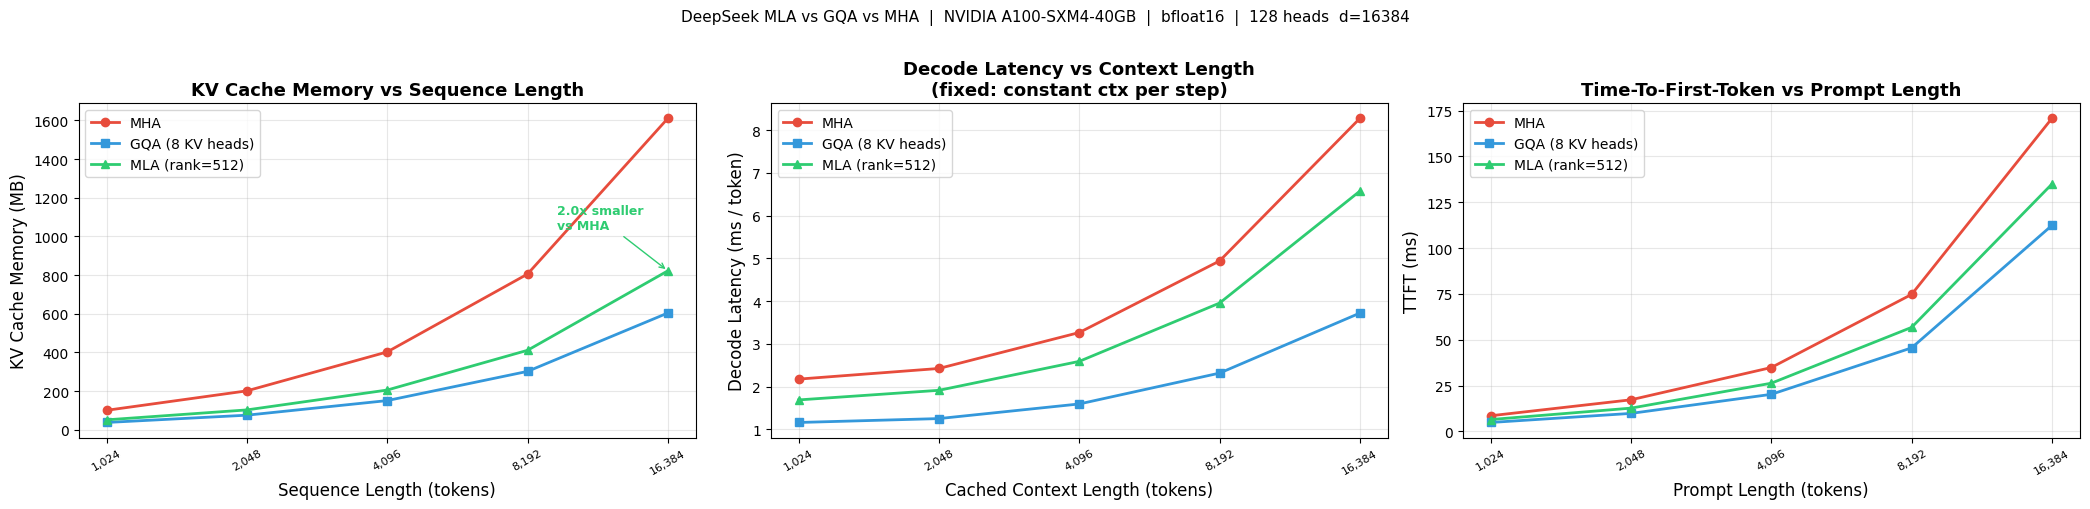

In [16]:
# ── Part 6 (Extended): Three-subplot figure ────────────────────────────────────
# Adds TTFT as a third subplot.  Decode latency uses lat_results_fixed
# (constant ctx per step) from Part 5 (Fixed).

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# ── Subplot 1: KV cache memory ───────────────────────────────────────────────
ax = axes[0]
ax.plot(mem_results['seq_lens'], mem_results['mha'], 'o-', color='#e74c3c', lw=2, ms=6, label='MHA')
ax.plot(mem_results['seq_lens'], mem_results['gqa'], 's-', color='#3498db', lw=2, ms=6, label=f'GQA ({NUM_KV_HEADS} KV heads)')
ax.plot(mem_results['seq_lens'], mem_results['mla'], '^-', color='#2ecc71', lw=2, ms=6, label=f'MLA (rank={KV_LORA_RANK})')
_p_mha = mem_results['mha'][-1]
_p_mla = mem_results['mla'][-1]
ax.annotate(
    f"{_p_mha/_p_mla:.1f}x smaller\nvs MHA",
    xy=(mem_results['seq_lens'][-1], _p_mla),
    xytext=(-80, 30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#2ecc71'),
    color='#2ecc71', fontsize=9, fontweight='bold'
)
ax.set_xscale('log', base=2)
ax.set_xlabel('Sequence Length (tokens)', fontsize=12)
ax.set_ylabel('KV Cache Memory (MB)', fontsize=12)
ax.set_title('KV Cache Memory vs Sequence Length', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xticks(mem_results['seq_lens'])
ax.set_xticklabels([f'{s:,}' for s in mem_results['seq_lens']], rotation=30, fontsize=8)

# ── Subplot 2: Decode latency (fixed — constant ctx per step) ────────────────
ax = axes[1]
ax.plot(lat_results_fixed['seq_lens'], lat_results_fixed['mha'], 'o-', color='#e74c3c', lw=2, ms=6, label='MHA')
ax.plot(lat_results_fixed['seq_lens'], lat_results_fixed['gqa'], 's-', color='#3498db', lw=2, ms=6, label=f'GQA ({NUM_KV_HEADS} KV heads)')
ax.plot(lat_results_fixed['seq_lens'], lat_results_fixed['mla'], '^-', color='#2ecc71', lw=2, ms=6, label=f'MLA (rank={KV_LORA_RANK})')
ax.set_xscale('log', base=2)
ax.set_xlabel('Cached Context Length (tokens)', fontsize=12)
ax.set_ylabel('Decode Latency (ms / token)', fontsize=12)
ax.set_title('Decode Latency vs Context Length\n(fixed: constant ctx per step)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xticks(lat_results_fixed['seq_lens'])
ax.set_xticklabels([f'{s:,}' for s in lat_results_fixed['seq_lens']], rotation=30, fontsize=8)

# ── Subplot 3: TTFT ───────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(ttft_results['seq_lens'], ttft_results['mha'], 'o-', color='#e74c3c', lw=2, ms=6, label='MHA')
ax.plot(ttft_results['seq_lens'], ttft_results['gqa'], 's-', color='#3498db', lw=2, ms=6, label=f'GQA ({NUM_KV_HEADS} KV heads)')
ax.plot(ttft_results['seq_lens'], ttft_results['mla'], '^-', color='#2ecc71', lw=2, ms=6, label=f'MLA (rank={KV_LORA_RANK})')
ax.set_xscale('log', base=2)
ax.set_xlabel('Prompt Length (tokens)', fontsize=12)
ax.set_ylabel('TTFT (ms)', fontsize=12)
ax.set_title('Time-To-First-Token vs Prompt Length', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xticks(ttft_results['seq_lens'])
ax.set_xticklabels([f'{s:,}' for s in ttft_results['seq_lens']], rotation=30, fontsize=8)

fig.suptitle(
    f'DeepSeek MLA vs GQA vs MHA  |  {gpu_name}  |  bfloat16  |  {NUM_HEADS} heads  d={D_MODEL}',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('mla_benchmark_results_extended.png', dpi=150, bbox_inches='tight')
print("Saved: mla_benchmark_results_extended.png")
plt.show()

In [17]:
!python decode_benchmark.py

GPU        : NVIDIA A100-SXM4-40GB
d_model    : 16384  (128 heads × 128 head_dim)
SEQ_LEN    : 4096
DTYPE      : torch.bfloat16

Instantiating models...
Models ready.

--- MHA ---
  mean decode latency: 3.51 ms/token
--- GQA ---
  mean decode latency: 1.59 ms/token
--- MLA ---
  mean decode latency: 2.55 ms/token

  Decode Latency Summary  |  ctx=4096  |  batch=1
  NVIDIA A100-SXM4-40GB  |  torch.bfloat16
   Model    ms/token      vs MHA      vs GQA
-------------------------------------------------------
     MHA        3.51       1.00x       2.21x
     GQA        1.59       0.45x       1.00x
     MLA        2.55       0.73x       1.61x


In [18]:
!/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/nsys profile --output=mla_decode --trace=cuda,nvtx --gpu-metrics-device=0 --force-overwrite=true python decode_benchmark.py

GPU 0: General Metrics for NVIDIA GA100 (any frequency)
GPU        : NVIDIA A100-SXM4-40GB
d_model    : 16384  (128 heads × 128 head_dim)
SEQ_LEN    : 4096
DTYPE      : torch.bfloat16

Instantiating models...
Models ready.

--- MHA ---
  mean decode latency: 3.53 ms/token
--- GQA ---
  mean decode latency: 1.62 ms/token
--- MLA ---
  mean decode latency: 2.59 ms/token

  Decode Latency Summary  |  ctx=4096  |  batch=1
  NVIDIA A100-SXM4-40GB  |  torch.bfloat16
   Model    ms/token      vs MHA      vs GQA
-------------------------------------------------------
     MHA        3.53       1.00x       2.17x
     GQA        1.62       0.46x       1.00x
     MLA        2.59       0.73x       1.60x
Generating '/tmp/nsys-report-c6a0.qdstrm'
[1/1] [========================100%] mla_decode.nsys-rep
Generated:
    /content/mla_decode.nsys-rep
